In [6]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import statsmodels

print("All packages are ready! ✅")

All packages are ready! ✅


In [8]:
# Load Air Quality Dataset

df = pd.read_csv("../data/air_quality_city_day.csv")

print("Dataset loaded successfully! ✅")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())


Dataset loaded successfully! ✅

Dataset Shape:
(29531, 16)

First 5 Rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



Column Names:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


In [9]:
# ============================================
# Step 3: Dataset Inspection
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\n" + "="*50)
print("Column Information")
print("="*50)

df.info()

print("\n" + "="*50)
print("Missing Values")
print("="*50)

missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\n" + "="*50)
print("Duplicate Rows")
print("="*50)

print("Number of duplicate rows:", df.duplicated().sum())

print("\n" + "="*50)
print("Numerical Summary")
print("="*50)

display(df.describe())

Dataset Shape:
(29531, 16)

Column Information
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB

Missing Values


Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
dtype: int64


Duplicate Rows
Number of duplicate rows: 0

Numerical Summary


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [10]:
# ============================================
# Step 4: Date Conversion & Missing Value Analysis
# ============================================

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Date range:")
print("Start:", df["Date"].min())
print("End  :", df["Date"].max())

print("\nNumber of unique cities:")
print(df["City"].nunique())

print("\nCities in dataset:")
print(df["City"].unique())

# Missing percentage
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_pct.round(2)
})

print("\nMissing Value Analysis:")
display(missing_table[missing_table["Missing Count"] > 0])

Date range:
Start: 2015-01-01 00:00:00
End  : 2020-07-01 00:00:00

Number of unique cities:
26

Cities in dataset:
<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str

Missing Value Analysis:


,Missing Count,Missing Percentage
AQI,4681,15.85
AQI_Bucket,4681,15.85
Benzene,5623,19.04
CO,2059,6.97
NH3,10328,34.97
NO,3582,12.13
NO2,3585,12.14
NOx,4185,14.17
O3,4022,13.62
PM10,11140,37.72


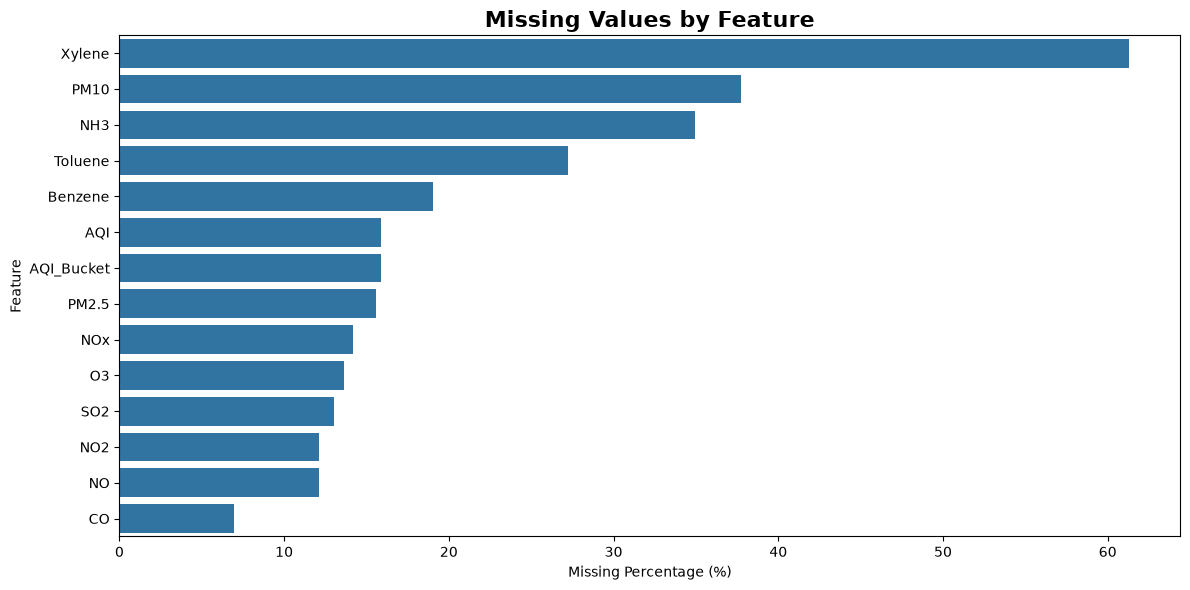

In [11]:
# ============================================
# Step 5: Missing Value Visualization
# ============================================

missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_pct.values,
    y=missing_pct.index
)

plt.title("Missing Values by Feature", fontsize=16, fontweight="bold")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

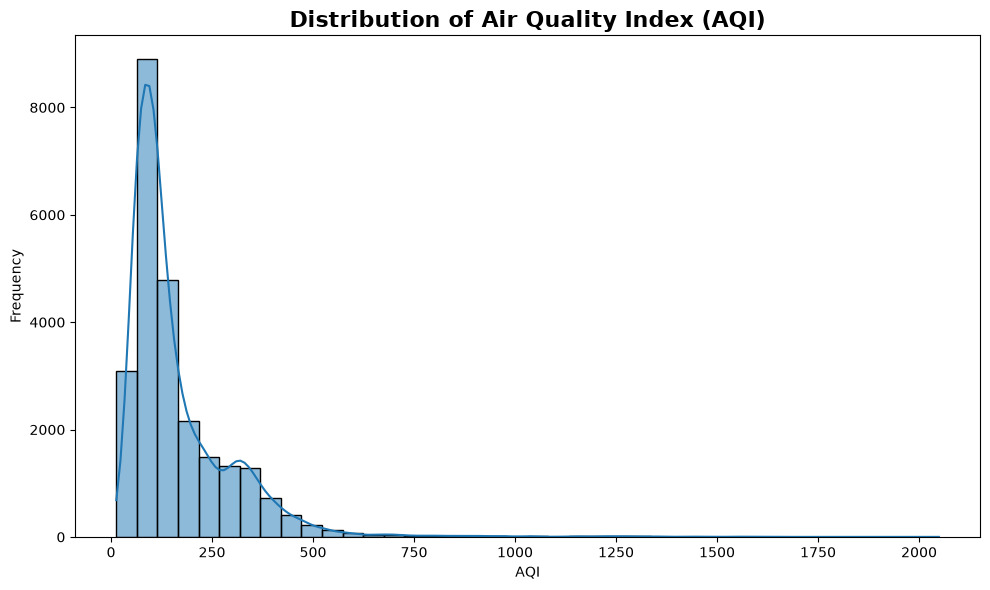

In [12]:
# ============================================
# Step 6: AQI Distribution
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["AQI"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Air Quality Index (AQI)", fontsize=16, fontweight="bold")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

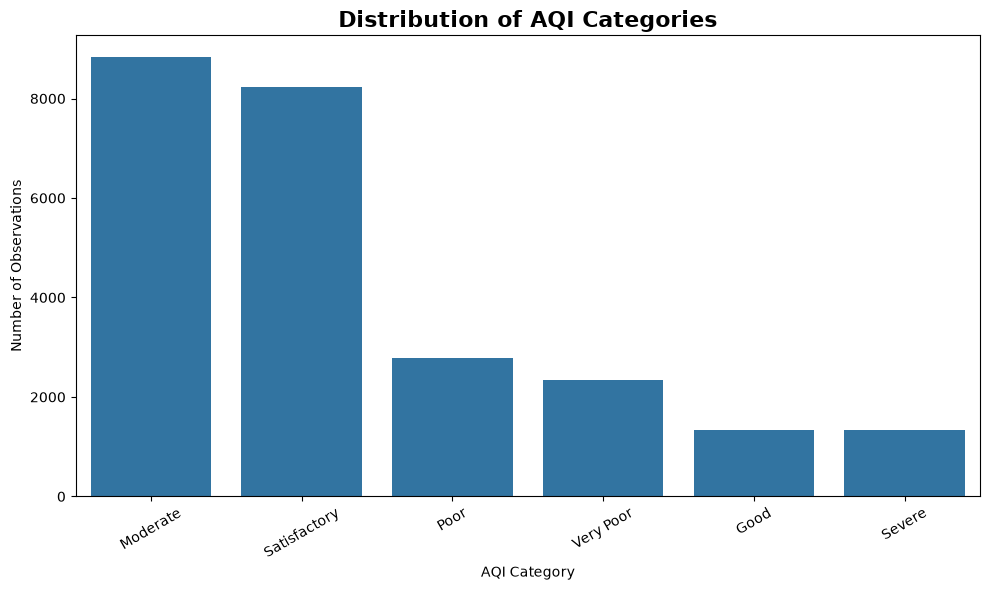

In [13]:
# ============================================
# Step 7: AQI Category Distribution
# ============================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="AQI_Bucket",
    order=df["AQI_Bucket"].value_counts().index
)

plt.title("Distribution of AQI Categories", fontsize=16, fontweight="bold")
plt.xlabel("AQI Category")
plt.ylabel("Number of Observations")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

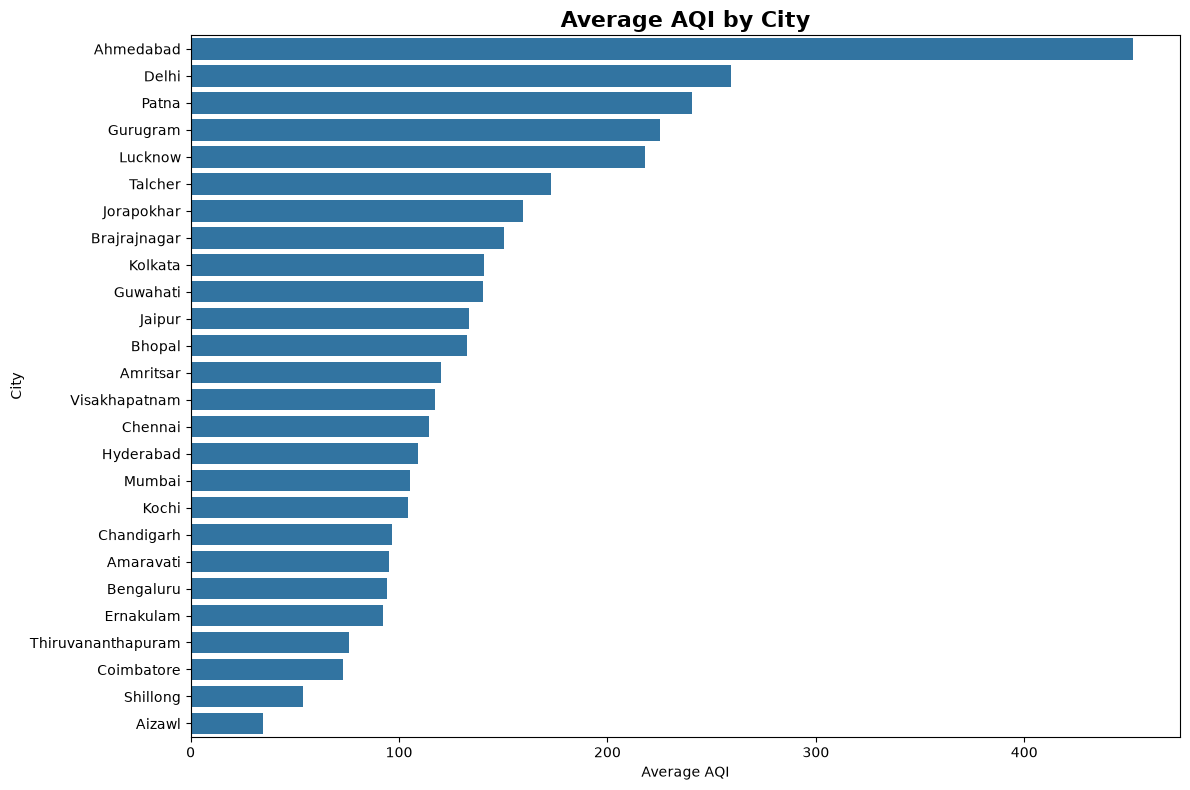

In [14]:
# ============================================
# Step 8: City-wise Average AQI
# ============================================

city_aqi = (
    df.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=city_aqi.values,
    y=city_aqi.index
)

plt.title(
    "Average AQI by City",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average AQI")
plt.ylabel("City")

plt.tight_layout()
plt.show()

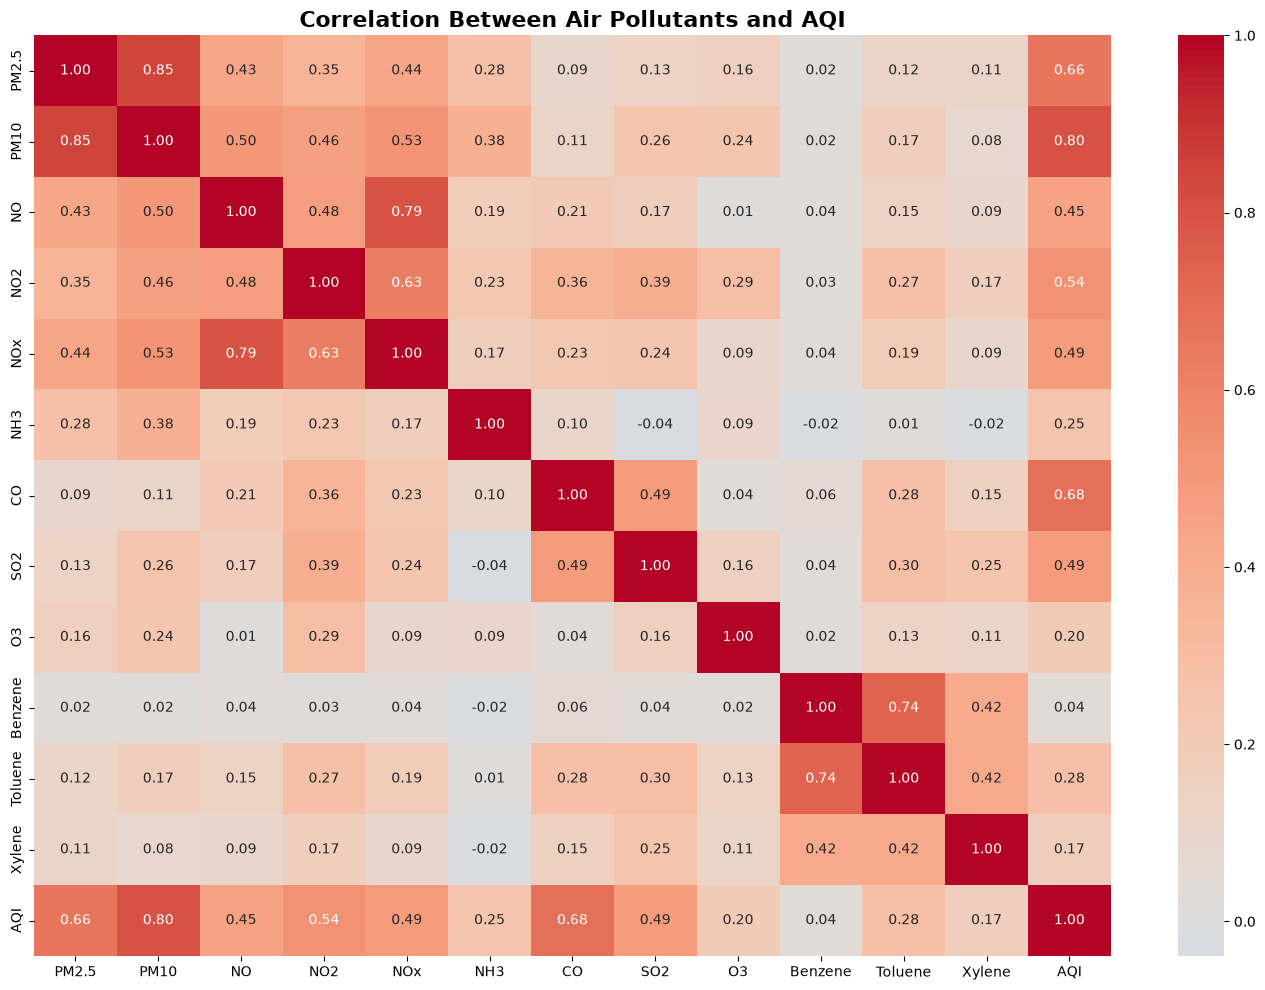

In [15]:
# ============================================
# Step 9: Pollutant Correlation Analysis
# ============================================

pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene", "AQI"
]

correlation = df[pollutants].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Between Air Pollutants and AQI",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [16]:
# ============================================
# Step 10: Prepare Data for AQI Modeling
# ============================================

# Work on a copy so the original dataset remains unchanged
aqi_df = df.copy()

# Remove rows where the target AQI is missing
aqi_df = aqi_df.dropna(subset=["AQI"])

print("Original dataset shape:", df.shape)
print("After removing missing AQI:", aqi_df.shape)

print("\nRemaining missing values:")
display(
    aqi_df.isnull().sum().sort_values(ascending=False)
)

Original dataset shape: (29531, 16)
After removing missing AQI: (24850, 16)

Remaining missing values:


Xylene        15372
PM10           7086
NH3            6536
Toluene        5826
Benzene        3535
NOx            1857
O3              807
PM2.5           678
SO2             605
CO              445
NO2             391
NO              387
Date              0
City              0
AQI               0
AQI_Bucket        0
dtype: int64

In [17]:
# ============================================
# Step 11: Handle Missing Pollutant Values
# ============================================

# Pollutant features
pollutants = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3",
    "Benzene", "Toluene", "Xylene"
]

# Create a copy
clean_df = aqi_df.copy()

# Fill missing pollutant values with their median
for column in pollutants:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

print("Missing values after median imputation:")
display(clean_df[pollutants].isnull().sum())

print("\nClean dataset shape:")
print(clean_df.shape)

Missing values after median imputation:


PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
dtype: int64


Clean dataset shape:
(24850, 16)


In [18]:
# ============================================
# Step 12: Prepare Features and Target
# ============================================

# Features
X = clean_df[pollutants]

# Target
y = clean_df["AQI"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used for prediction:")
print(X.columns.tolist())

print("\nTarget:")
print("AQI")

print("\nFirst 5 feature rows:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

Feature shape: (24850, 12)
Target shape: (24850,)

Features used for prediction:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

Target:
AQI

First 5 feature rows:


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene
28,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,3.14
29,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,4.81
30,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,7.67
31,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,25.87
32,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,35.61



First 5 target values:


28    209.0
29    328.0
30    514.0
31    782.0
32    914.0
Name: AQI, dtype: float64

In [19]:
# ============================================
# Step 13: Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("\nTraining Target:", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features: (19880, 12)
Testing Features : (4970, 12)

Training Target: (19880,)
Testing Target : (4970,)


In [20]:
# ============================================
# Step 14: Linear Regression Baseline
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Evaluate
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("LINEAR REGRESSION RESULTS")
print("=" * 40)
print(f"MAE  : {mae_linear:.2f}")
print(f"RMSE : {rmse_linear:.2f}")
print(f"R²   : {r2_linear:.4f}")

LINEAR REGRESSION RESULTS
MAE  : 31.17
RMSE : 59.44
R²   : 0.8070


In [21]:
# ============================================
# Step 15: Random Forest Regressor
# ============================================

from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST RESULTS")
print("=" * 40)
print(f"MAE  : {mae_rf:.2f}")
print(f"RMSE : {rmse_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

RANDOM FOREST RESULTS
MAE  : 20.76
RMSE : 40.68
R²   : 0.9096


In [22]:
# ============================================
# Step 16: Gradient Boosting Regressor
# ============================================

from sklearn.ensemble import GradientBoostingRegressor

# Create model
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluation
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("GRADIENT BOOSTING RESULTS")
print("=" * 40)
print(f"MAE  : {mae_gb:.2f}")
print(f"RMSE : {rmse_gb:.2f}")
print(f"R²   : {r2_gb:.4f}")

GRADIENT BOOSTING RESULTS
MAE  : 23.59
RMSE : 43.56
R²   : 0.8964


In [23]:
# ============================================
# Step 17: Ridge Regression
# ============================================

from sklearn.linear_model import Ridge

# Create model
ridge_model = Ridge(alpha=1.0)

# Train
ridge_model.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_model.predict(X_test)

# Evaluation
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("RIDGE REGRESSION RESULTS")
print("=" * 40)
print(f"MAE  : {mae_ridge:.2f}")
print(f"RMSE : {rmse_ridge:.2f}")
print(f"R²   : {r2_ridge:.4f}")

RIDGE REGRESSION RESULTS
MAE  : 31.17
RMSE : 59.44
R²   : 0.8070


In [24]:
# ============================================
# Step 18: Random Forest Hyperparameter Tuning
# ============================================

from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", "log2"]
}

rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-rf_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}

Best Cross-Validation RMSE:
44.06528081975687


In [25]:
# ============================================
# Step 19: Evaluate Tuned Random Forest
# ============================================

# Get the best tuned model
tuned_rf = rf_search.best_estimator_

# Predict on the untouched test set
y_pred_tuned_rf = tuned_rf.predict(X_test)

# Calculate metrics
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mean_squared_error(y_test, y_pred_tuned_rf))
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print("TUNED RANDOM FOREST RESULTS")
print("=" * 40)
print(f"MAE  : {mae_tuned_rf:.2f}")
print(f"RMSE : {rmse_tuned_rf:.2f}")
print(f"R²   : {r2_tuned_rf:.4f}")

TUNED RANDOM FOREST RESULTS
MAE  : 20.72
RMSE : 40.09
R²   : 0.9122


Feature Importance:


PM2.5      0.304169
CO         0.258428
PM10       0.102650
SO2        0.065459
NO         0.063380
NO2        0.058021
NOx        0.052393
Toluene    0.032103
Xylene     0.017747
O3         0.015744
NH3        0.015535
Benzene    0.014372
dtype: float64

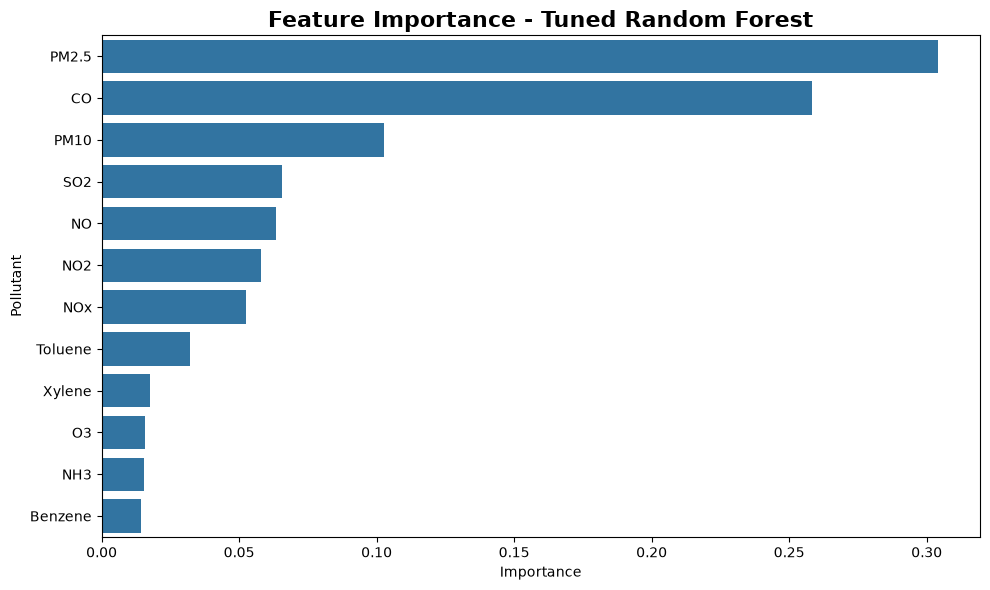

In [26]:
# ============================================
# Step 20: Feature Importance
# ============================================

feature_importance = pd.Series(
    tuned_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
display(feature_importance)

# Visualization
plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,
    y=feature_importance.index
)

plt.title(
    "Feature Importance - Tuned Random Forest",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Pollutant")

plt.tight_layout()
plt.show()

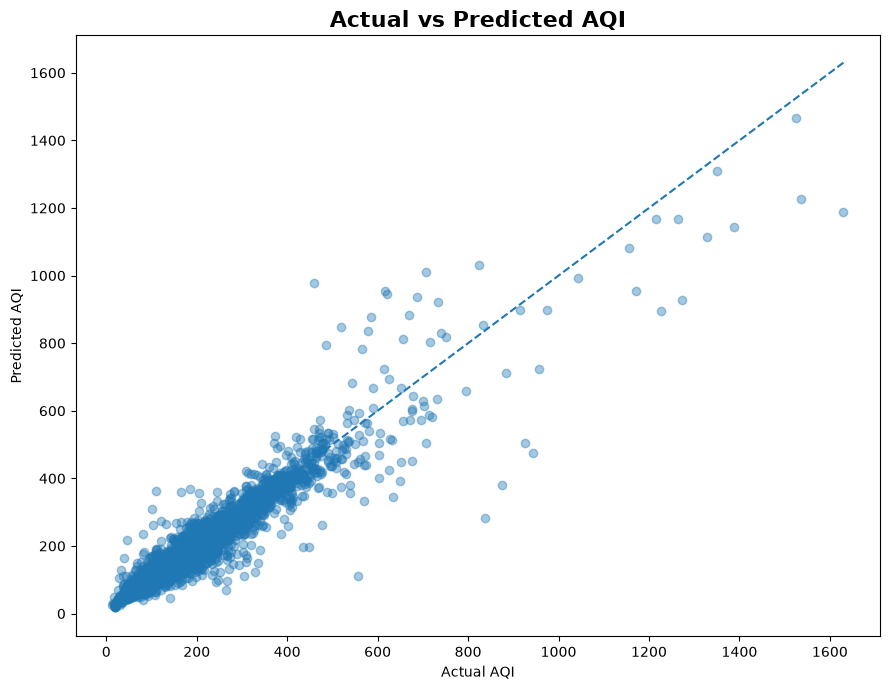

In [27]:
# ============================================
# Step 21: Actual vs Predicted AQI
# ============================================

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    y_pred_tuned_rf,
    alpha=0.4
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_tuned_rf.min())
max_value = max(y_test.max(), y_pred_tuned_rf.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title(
    "Actual vs Predicted AQI",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.tight_layout()
plt.show()

Residual Statistics
Mean Error       : -0.86
Median Error     : -3.31
Maximum Error    : 555.50
Minimum Error    : -519.05


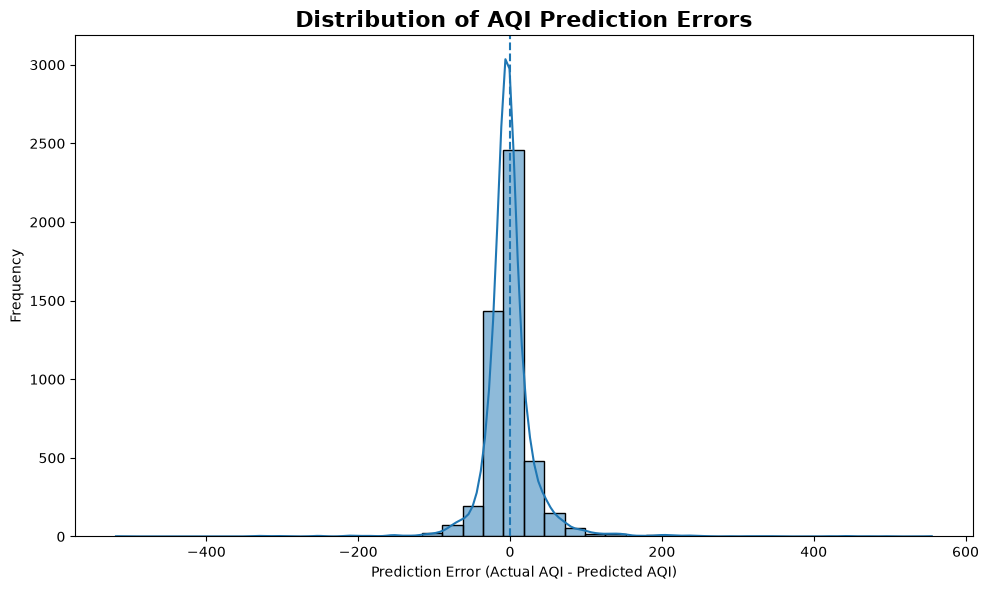

In [28]:
# ============================================
# Step 22: Prediction Error Analysis
# ============================================

# Calculate prediction errors
residuals = y_test - y_pred_tuned_rf

print("Residual Statistics")
print("=" * 40)
print(f"Mean Error       : {residuals.mean():.2f}")
print(f"Median Error     : {residuals.median():.2f}")
print(f"Maximum Error    : {residuals.max():.2f}")
print(f"Minimum Error    : {residuals.min():.2f}")

# Residual distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribution of AQI Prediction Errors",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Prediction Error (Actual AQI - Predicted AQI)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [29]:
# ============================================
# Step 23: Final Model Comparison
# ============================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_ridge,
        mae_rf,
        mae_gb,
        mae_tuned_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_ridge,
        rmse_rf,
        rmse_gb,
        rmse_tuned_rf
    ],
    "R2": [
        r2_linear,
        r2_ridge,
        r2_rf,
        r2_gb,
        r2_tuned_rf
    ]
})

results = results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

display(results.round(4))

,Model,MAE,RMSE,R2
0,Tuned Random Forest,20.7153,40.0896,0.9122
1,Random Forest,20.7625,40.6756,0.9096
2,Gradient Boosting,23.5926,43.5645,0.8964
3,Ridge Regression,31.1705,59.4416,0.8070
4,Linear Regression,31.1705,59.4417,0.8070


In [30]:
# ============================================
# Step 24: Save Final Model
# ============================================

import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save trained model
model_path = "../models/final_aqi_model.pkl"
joblib.dump(tuned_rf, model_path)

# Save feature columns
features_path = "../models/aqi_feature_columns.pkl"
joblib.dump(list(X.columns), features_path)

print("Final model saved successfully! ✅")
print("Model:", model_path)
print("Features:", features_path)

Final model saved successfully! ✅
Model: ../models/final_aqi_model.pkl
Features: ../models/aqi_feature_columns.pkl


In [31]:
# ============================================
# Step 25: Verify Saved Model
# ============================================

import joblib

# Load saved model
loaded_model = joblib.load("../models/final_aqi_model.pkl")

# Load saved feature columns
loaded_features = joblib.load("../models/aqi_feature_columns.pkl")

print("Model loaded successfully! ✅")
print("Number of features:", len(loaded_features))
print("Features:", loaded_features)

# Test prediction using the first test record
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

print("\nSample AQI Prediction:")
print(f"Predicted AQI: {prediction:.2f}")

print(f"Actual AQI: {y_test.iloc[0]:.2f}")

Model loaded successfully! ✅
Number of features: 12
Features: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

Sample AQI Prediction:
Predicted AQI: 96.61
Actual AQI: 141.00
